# **Bibliotecas utilizadas**

# **KNN com 5 vizinhos para o dataset do vinho e mostrar a acurácia**

In [23]:
#Importando Bibliotecas

import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from collections import Counter

In [24]:
#Classe KNN feito em aula com até 5 vizinhos

class KNN:
    def __init__(self, k=5, d='euclidean'):
        """
        Inicializa o classificador KNN com o número de vizinhos.

        Parâmetros:
        k (int): Número de vizinhos a considerar. 5 vizinhos.
        """
        self.k = k
        self.d = d

    def distance(self, x1):
        if self.d == 'euclidean':
            # Calcula distância Euclidean sem a soma extra
            D = np.sqrt(np.sum((x1 - self.X)**2, axis=1))
        else:
            D = np.sum(np.abs(x1 - self.X), axis=1)
        return D

    def fit(self, X, y):
        """
        Ajusta o modelo KNN armazenando o conjunto de dados de treinamento.

        Parâmetros:
        X_train (array numpy): Características de treinamento.
        y_train (array numpy): Rótulos de treinamento.
        """
        self.X = X
        self.y = y

    def predict(self, X_pred):
        y_pred = []
        for x in X_pred:
            # Calcula as distâncias entre x e todos os pontos em self.X
            distancias = np.sqrt(np.sum((self.X - x)**2, axis=1))

            # Obtém os índices dos k vizinhos mais próximos
            idx_viz = np.argsort(distancias)[:self.k]

            # Obtém os rótulos dos k vizinhos mais próximos
            # Convertendo idx_viz para uma lista para garantir a compatibilidade com a indexação do pandas
            y_viz = self.y.iloc[idx_viz]

            # Faz a predição com base na classe mais frequente entre os vizinhos
            pred = max(set(y_viz), key=y_viz.tolist().count)
            y_pred.append(pred)
        return np.array(y_pred)

In [14]:
#Separando o alvo do dataset
data = datasets.load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [15]:
# Verificando as informações do dataset
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [16]:
# Verificando se existe valores ausentes
print("Verificando valores ausentes no dataset:")
print(df.isna().sum())

Verificando valores ausentes no dataset:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [17]:
#Separando Caracteristica do alvo
X_treino = df.drop('target', axis=1)
y_treino = df['target']

In [18]:
# Dividindo o dataset em treino e validação
X_treino, X_teste, y_treino, y_teste = train_test_split(X_treino, y_treino, test_size=0.2, random_state=100)

In [19]:
#Normalizando os dados

scaler = StandardScaler()
X_train = scaler.fit_transform(X_treino)
X_test = scaler.transform(X_teste)

In [20]:
# Colocando a classe KNN com 5 vizinhos próximos
knn = KNN(k=5, d='euclidean')

In [21]:
#Modelo KNN
knn.fit(X_train, y_treino)
pred = knn.predict(X_test)
print('Acurácia: ', np.sum(pred == y_teste)/len(y_teste))

Acurácia:  0.9166666666666666


# **KNN do Sklearn para o dataset dos Dígitos e printar resultados com classification report para 3 e 7 vizinhos**

In [48]:
#Importando Bibliotecas

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [49]:
#Separando Caracteristica do alvo
data_digits = datasets.load_digits()
X_digits = data_digits.data
y_digits = data_digits.target

In [50]:
# Dividindo o dataset em Treino e validação
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.2, random_state=100)

In [51]:
#Normalizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
# treinando o modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)


In [55]:
#Treinando o modelo e mostrando o classification report de KNN 3 e 7
acc = []

for i in [3, 7]:
    knn_sk = KNeighborsClassifier(n_neighbors=i)
    knn_sk.fit(X_train, y_train)
    res = classification_report(y_test, knn_sk.predict(X_test))
    acc.append(res)
    print(f'Acurácia para k = {i}: {res}')

Acurácia para k = 3:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       0.97      0.97      0.97        32
           2       0.98      0.98      0.98        41
           3       1.00      0.97      0.98        32
           4       1.00      0.97      0.99        36
           5       1.00      1.00      1.00        35
           6       0.98      1.00      0.99        40
           7       0.95      1.00      0.97        39
           8       0.96      0.96      0.96        27
           9       0.97      0.94      0.96        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

Acurácia para k = 7:               precision    recall  f1-score   support

           0       0.98      1.00      0.99        42
           1       0.94      0.97      0.95        32
           2       1.00      0.95   

# **Kmeans do Sklearn no dataset data.csv com o método do cotovelo.**

In [56]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [58]:
# Importando o dataset
df_dataset = pd.read_csv( '/content/data.csv', sep=',')

In [59]:
df_dataset.head()

,f1,f2
0,1.842080,4.607572
1,5.658583,4.799964
2,6.352579,3.290854
3,2.904017,4.612204
4,3.231979,4.939894


In [65]:
# pega os valores do dataframe
X = df_dataset.values


In [62]:
# Método do Cotovelo para determinar o número de clusters
inercia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

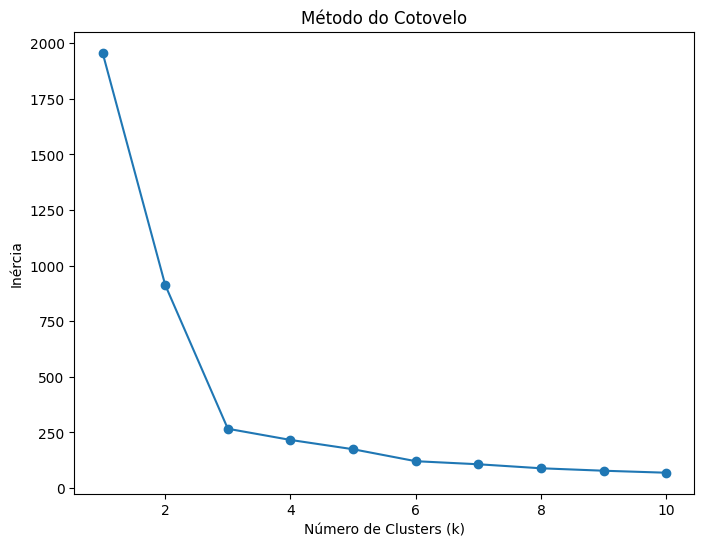

In [64]:
# Plotar o gráfico do método do cotovelo
plt.figure(figsize=(8,6))
plt.plot(K_range, inercia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.show()

In [67]:
# Treinando com o número de clusters encontrado
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

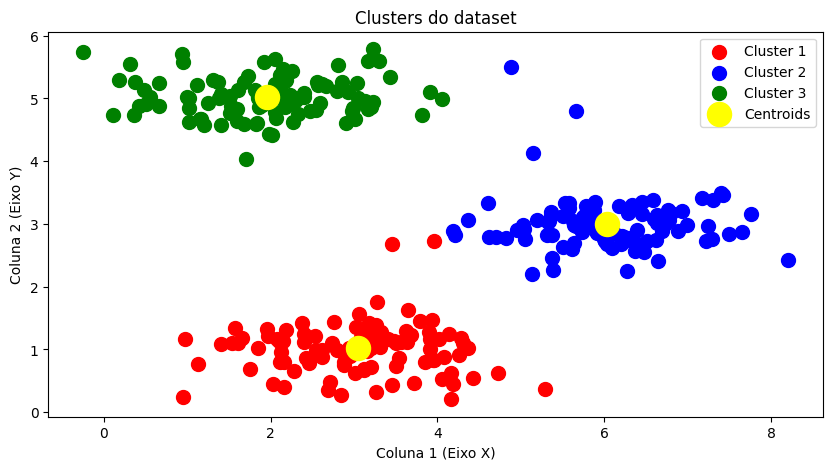

In [69]:
plt.figure(figsize=(10,5))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters do dataset')
plt.xlabel('Coluna 1 (Eixo X)')
plt.ylabel('Coluna 2 (Eixo Y)')
plt.legend()
plt.show()